In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,StandardScaler,FunctionTransformer
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error,mean_absolute_error, mean_squared_error,r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [2]:
df=pd.read_csv("Data/housing.csv").copy()

In [3]:
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

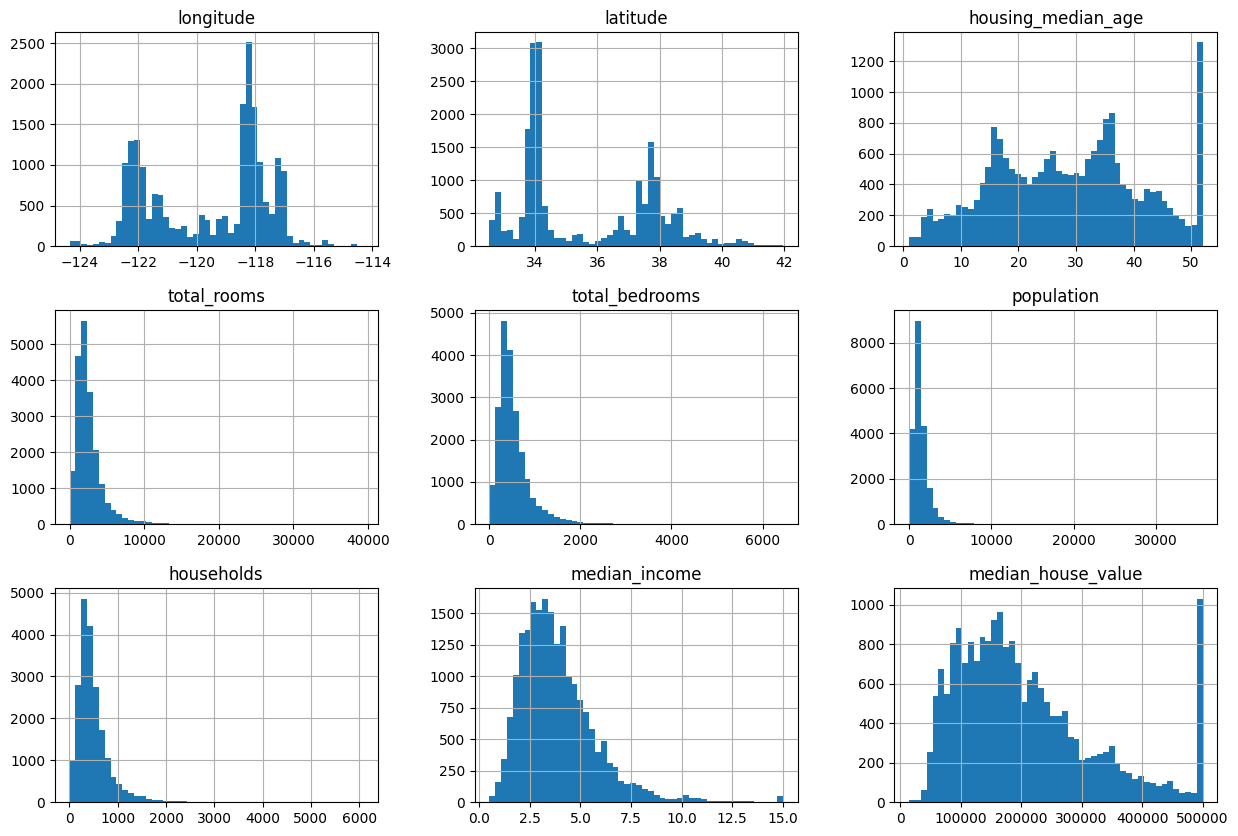

In [7]:
df.hist(bins=50,figsize=(15,10))
plt.show()

In [8]:
df["rooms_per_house"]=df["total_rooms"]/df["households"]
df["bedrooms_ratio"]=df["total_bedrooms"]/df["total_rooms"]
df["people_per_house"]=df["population"]/df["households"]

In [9]:
x = df.drop("median_house_value",axis=1)
y = df["median_house_value"]

In [10]:
x = pd.get_dummies(x,drop_first=True)

In [11]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [12]:
num_attribute = x.columns

In [13]:
num_pipeline = Pipeline([
    ('Standard Scaler',StandardScaler()),
    ('Imputer',SimpleImputer())
])
full_pipeline = ColumnTransformer([
    ("num",num_pipeline,num_attribute)
])

In [14]:
def evaluation(y_pred):
    print("Analysis")
    print(f"RMSE: {root_mean_squared_error(y_test,pred)}")
    print(f"MAE : {mean_absolute_error(y_test,pred)}")
    print(f"MSE : {mean_squared_error(y_test,pred)}")
    print(f"R2  : {r2_score(y_test,pred)}")
    
    np.random.seed(42)
    indices = np.random.choice(len(y_test), 80, replace=False)
    
    actual = np.array(y_test)[indices]
    predicted = np.array(pred)[indices]
    plt.figure(figsize=(15,10))
    plt.plot(actual,marker='o', label="Actual")
    plt.plot(predicted,marker='o', label="Predicted")
    
    plt.xlabel("Sample")
    plt.ylabel("Value")
    plt.title("Actual vs Predicted Values")
    plt.legend()
    
    plt.show()

In [15]:
lin_reg = make_pipeline(full_pipeline,LinearRegression(n_jobs=-1))
lin_reg.fit(x_train,y_train)

,steps,"[('columntransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Linear Regression
Analysis
RMSE: 69121.10475860804
MAE : 49657.39491777881
MSE : 4777727123.0504675
R2  : 0.6354018323757127


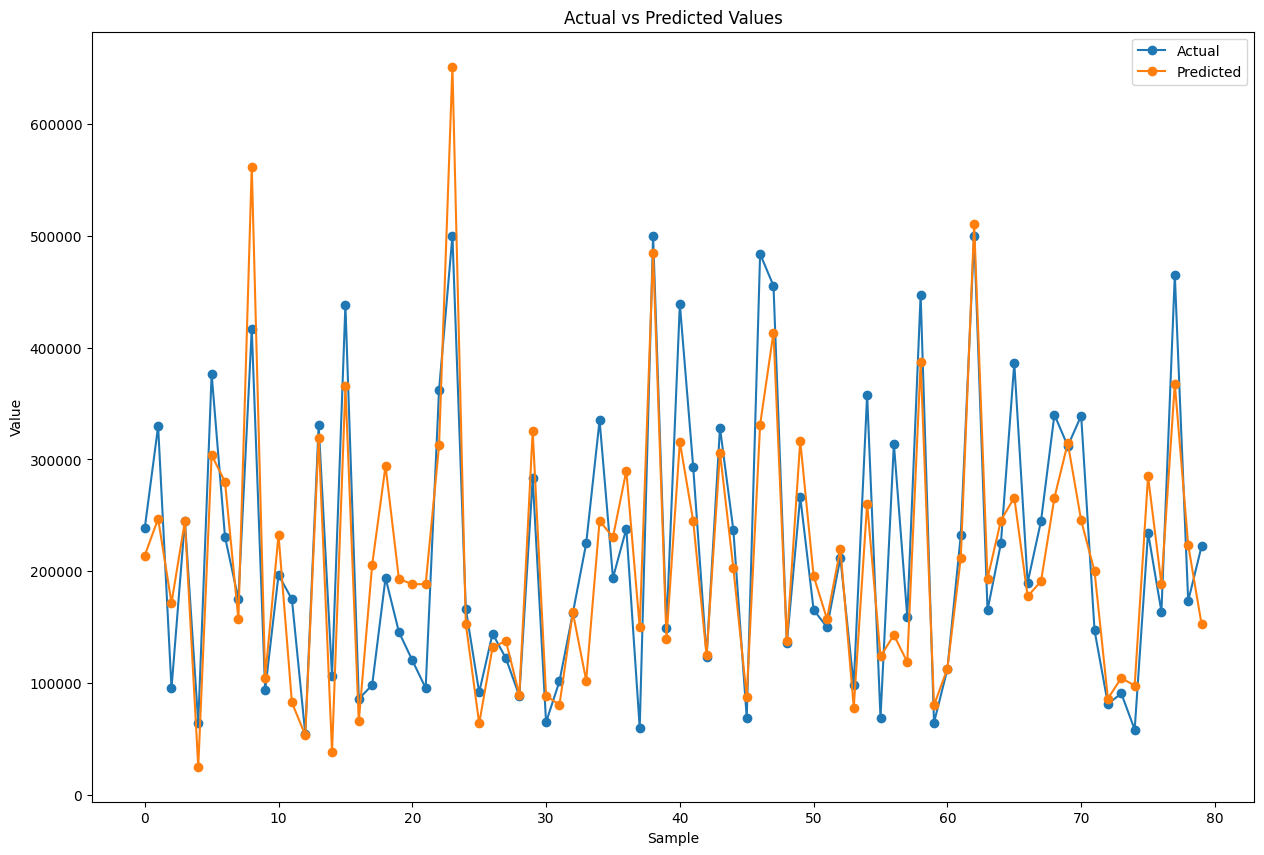

In [16]:
pred = lin_reg.predict(x_test)
print("Linear Regression")
evaluation(pred)

In [17]:
dec_tre = make_pipeline(full_pipeline, DecisionTreeRegressor(random_state=42))
dec_tre.fit(x_train,y_train)

,steps,"[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Decission Tree
Analysis
RMSE: 70394.16680002483
MAE : 43321.310804263565
MSE : 4955338719.469719
R2  : 0.6218479267349195


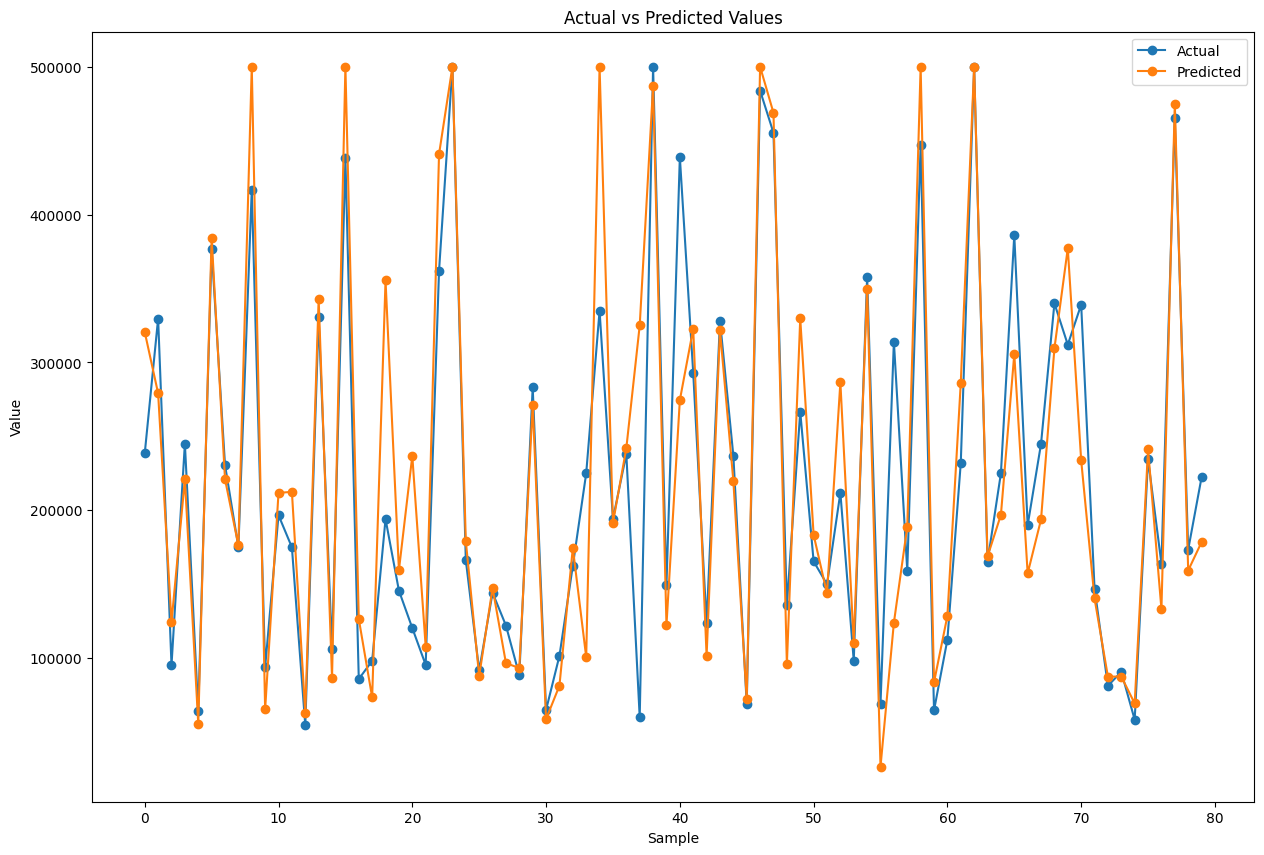

In [18]:
pred = dec_tre.predict(x_test)
print("Decission Tree")
evaluation(pred)

In [19]:
ran_for = make_pipeline(full_pipeline,RandomForestRegressor(n_jobs=-1,random_state=42))
ran_for.fit(x_train,y_train)

,steps,"[('columntransformer', ...), ('randomforestregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Random Forest
Analysis
RMSE: 49808.01951312418
MAE : 31927.012713178294
MSE : 2480838807.819759
R2  : 0.810682096275771


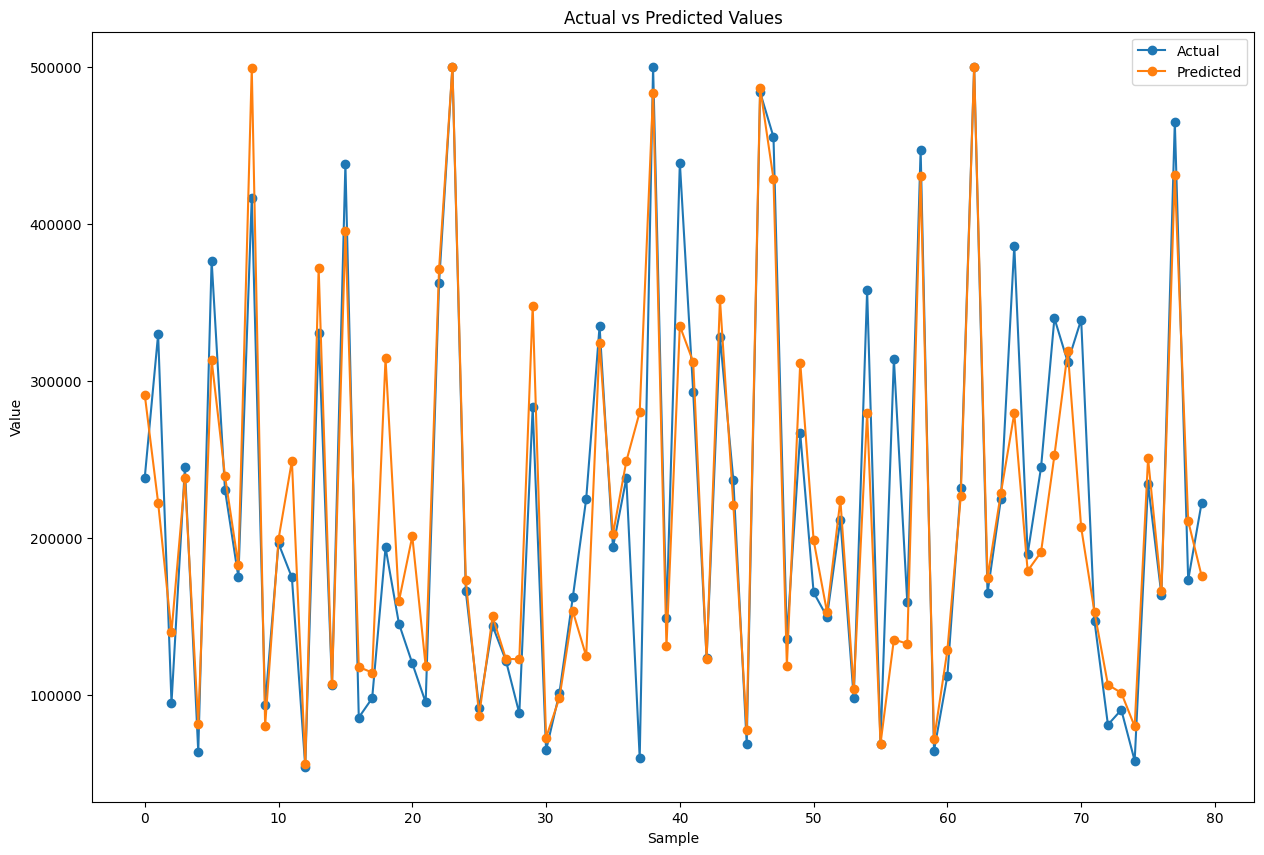

In [20]:
pred = ran_for.predict(x_test)
print("Random Forest")
evaluation(pred)

In [21]:
xg_boost = make_pipeline(full_pipeline,XGBRegressor())
xg_boost.fit(x_train,y_train)

,steps,"[('columntransformer', ...), ('xgbregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


XG Boost
Analysis
RMSE: 46039.62232085698
MAE : 30263.093125454216
MSE : 2119646823.4471521
R2  : 0.8382453982959902


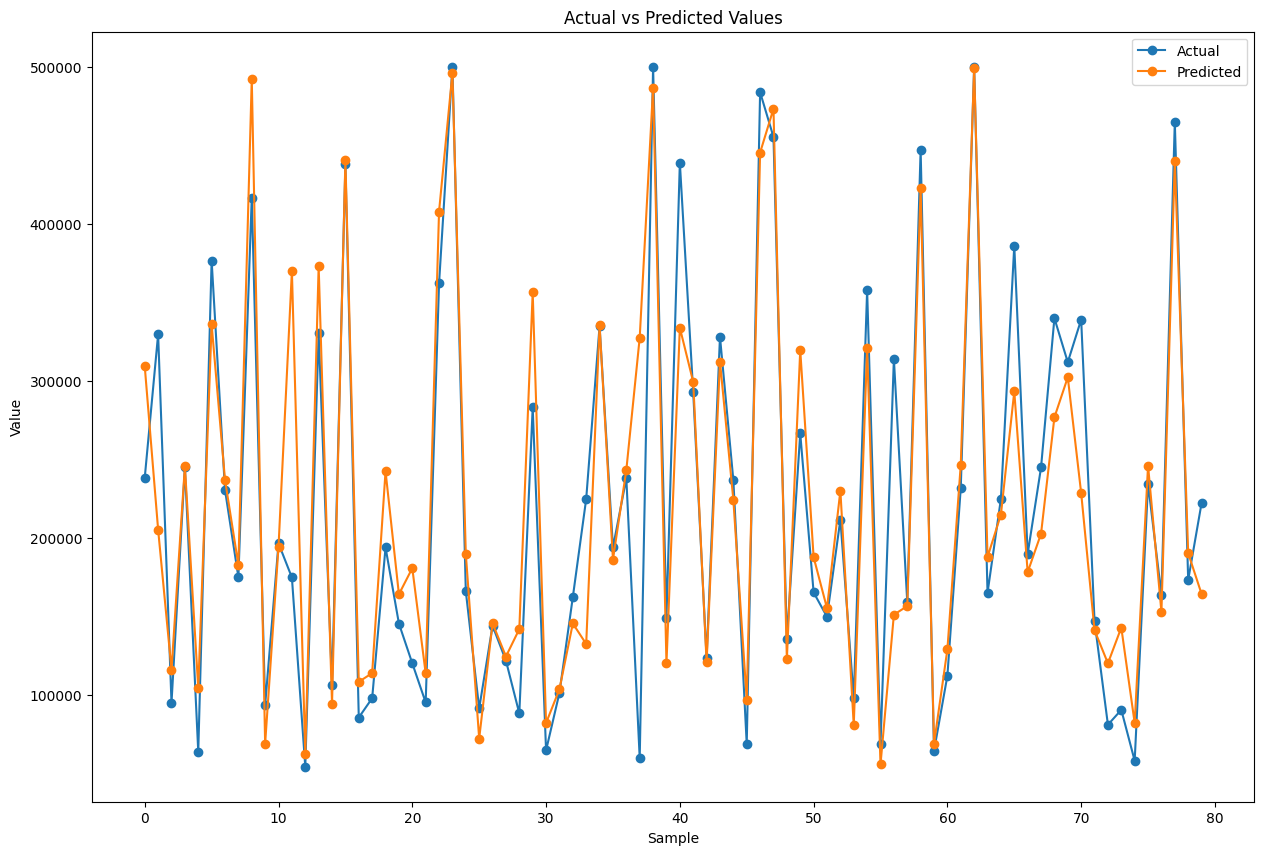

In [22]:
pred = xg_boost.predict(x_test)
print("XG Boost")
evaluation(pred)

In [23]:
xg_boost.named_steps

{'columntransformer': ColumnTransformer(transformers=[('num',
                                  Pipeline(steps=[('Standard Scaler',
                                                   StandardScaler()),
                                                  ('Imputer', SimpleImputer())]),
                                  Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
        'total_bedrooms', 'population', 'households', 'median_income',
        'rooms_per_house', 'bedrooms_ratio', 'people_per_house',
        'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
        'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN'],
       dtype='object'))]),
 'xgbregressor': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights

In [24]:
xgb = make_pipeline(full_pipeline,XGBRegressor())
param_grid = {
    'xgbregressor__n_estimators': [100, 200, 300],
    'xgbregressor__max_depth': [3, 5, 7],
    'xgbregressor__learning_rate': [0.01, 0.05, 0.1],
    'xgbregressor__subsample': [0.8, 1.0],
    'xgbregressor__colsample_bytree': [0.8, 1.0],
    'xgbregressor__min_child_weight': [1, 3, 5],
    'xgbregressor__gamma': [0, 0.1, 0.2]
}
grid_search = GridSearchCV(
    xgb,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring="neg_root_mean_squared_error",
)
grid_search.fit(x_train,y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'xgbregressor__colsample_bytree': [0.8, 1.0], 'xgbregressor__gamma': [0, 0.1, ...], 'xgbregressor__learning_rate': [0.01, 0.05, ...], 'xgbregressor__max_depth': [3, 5, ...], ...}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...)]"


In [25]:
print("Best Parameter")
print(grid_search.best_params_)

Best Parameter
{'xgbregressor__colsample_bytree': 0.8, 'xgbregressor__gamma': 0, 'xgbregressor__learning_rate': 0.1, 'xgbregressor__max_depth': 7, 'xgbregressor__min_child_weight': 3, 'xgbregressor__n_estimators': 300, 'xgbregressor__subsample': 1.0}


XG Boost
Analysis
RMSE: 43769.23845445119
MAE : 28329.03046364008
MSE : 1915746234.882609
R2  : 0.8538054709107444


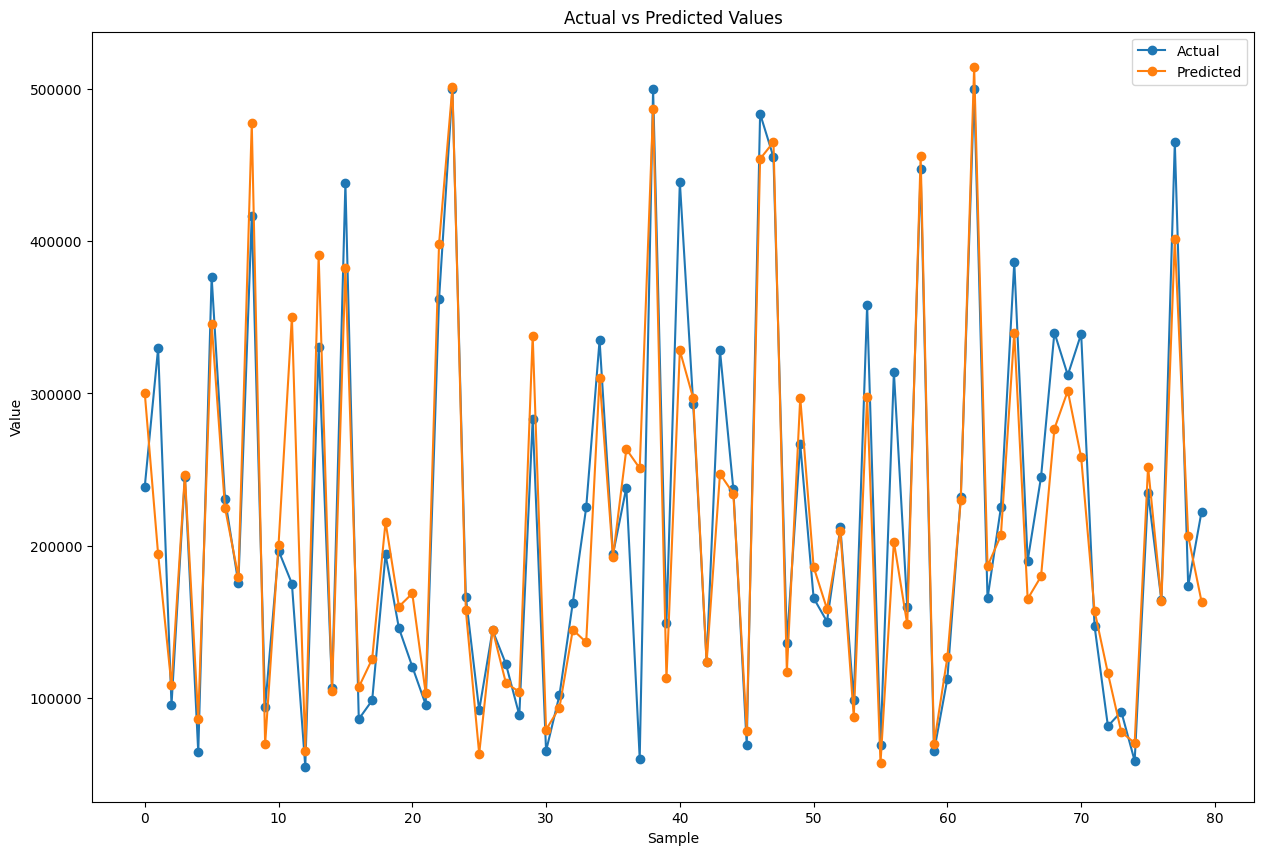

In [26]:
model=grid_search.best_estimator_
pred = model.predict(x_test)
print("XG Boost")
evaluation(pred)